# 1. Import Data

In [14]:
# Global Import and Directories
import sys
sys.path.append("..")
import Setup
from Setup import *

In [15]:
# Extract information from json files
def load_test_metrics_per_h_avg_over_seeds(
    base_dir: str | Path,
    filename: str = "train_summary.json",
    keep_seed_level: bool = False,
) -> pd.DataFrame:
    
    base_dir = Path(base_dir)
    if not base_dir.exists():
        raise FileNotFoundError(f"base_dir not found: {base_dir}")

    json_files = sorted(base_dir.rglob(filename))
    if not json_files:
        raise FileNotFoundError(f"No {filename} found under {base_dir}")

    def safe_load_json(path: Path) -> dict:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)

    rows = []

    for jf in json_files:
        data = safe_load_json(jf)

        exp_dir = jf.parent
        exp_name = exp_dir.name  # oder: str(exp_dir.relative_to(base_dir))
        mode = data.get("mode", None)

        per_seed = data.get("per_seed", []) or []
        if not per_seed:
            continue

        for seed_block in per_seed:
            seed = seed_block.get("seed", None)
            metrics = seed_block.get("metrics", {}) or {}
            test_per_h = metrics.get("test_per_h", {}) or {}

            for horizon_raw, vals in test_per_h.items():
                try:
                    horizon = int(horizon_raw)
                except Exception:
                    horizon = horizon_raw

                vals = vals or {}
                rows.append(
                    {
                        "experiment": exp_name,
                        "experiment_dir": str(exp_dir),
                        "file": str(jf),
                        "mode": mode,
                        "seed": seed,
                        "horizon": horizon,
                        "MAE": vals.get("MAE", None),
                        "RMSE": vals.get("RMSE", None),
                        "MAPE": vals.get("MAPE", None),
                    }
                )

    df_seed = pd.DataFrame(rows)

    if df_seed.empty:
        return df_seed

    # sicherstellen, dass Metriken numeric sind (falls mal Strings auftauchen)
    for c in ["MAE", "RMSE", "MAPE"]:
        if c in df_seed.columns:
            df_seed[c] = pd.to_numeric(df_seed[c], errors="coerce")

    df_avg = (
        df_seed
        .groupby(["experiment", "horizon"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            MAE_mean=("MAE", "mean"),
            RMSE_mean=("RMSE", "mean"),
            MAPE_mean=("MAPE", "mean"),
        )
        .sort_values(["experiment", "horizon"])
        .reset_index(drop=True)
    )

    if keep_seed_level:
        return df_avg, df_seed

    return df_avg

In [16]:
# Export Table to tex
def df_avg_to_latex_table_named_sorted_2dec(
    df_avg: pd.DataFrame,
    horizons: list[int],
    minutes: dict[int, str] | None = None,
    save_path: str | Path | None = None,
) -> str:

    if minutes is None:
        minutes = {h: f"{15*h}min" for h in horizons}

    rename_map = {
        "00_Base": "STGNN",
        "01_use_temp_day": "STGNN w/o DE",
        "02_use_temp_week": "STGNN w/o WE",
        "03_use_temp_day_week": "STGNN w/o TE and WE",
        "04_use_spatial": "STGNN w/o GCN",
        "05_use_attention": "STGNN w/o AT",
        "06_use_time": "STGNN w/o TE",
        "07_use_condat": "STGNN w/o Station Details",
        "08_use_distance": "STGNN Radius-Base",
    }

    df_f = df_avg[df_avg["horizon"].isin(horizons)].copy()
    if df_f.empty:
        raise ValueError(f"Keine Daten für horizons={horizons} gefunden.")

    df_wide = df_f.pivot_table(
        index="experiment",
        columns="horizon",
        values=["MAE_mean", "MAPE_mean", "RMSE_mean"],
        aggfunc="mean",
    )

    ordered_cols = []
    for h in horizons:
        ordered_cols += [("MAE_mean", h), ("MAPE_mean", h), ("RMSE_mean", h)]
    df_wide = df_wide[ordered_cols].copy()

    # Sortierung: 00... oben
    df_wide = df_wide.sort_index()

    # MAPE -> Prozent
    for h in horizons:
        if ("MAPE_mean", h) in df_wide.columns:
            df_wide[("MAPE_mean", h)] = df_wide[("MAPE_mean", h)] * 100

    # MultiIndex Header
    top = []
    sub = []
    for metric, h in df_wide.columns:
        top.append(f"Horizon {h} ({minutes[h]})")
        sub.append("MAE" if metric == "MAE_mean" else "MAPE" if metric == "MAPE_mean" else "RMSE")
    df_wide.columns = pd.MultiIndex.from_arrays([top, sub])

    df_out = df_wide.reset_index().rename(columns={"experiment": "Experiment"})
    df_out["Experiment"] = df_out["Experiment"].map(lambda x: rename_map.get(x, x))

    latex = df_out.to_latex(
        index=False,
        escape=False,
        multicolumn=True,
        multicolumn_format="c",
        column_format="l" + "ccc" * len(horizons),
        float_format="%.2f",
    )

    latex = latex.replace("%", r"\%")

    # ---------- speichern ----------
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        save_path.write_text(latex, encoding="utf-8")

    return latex


In [17]:
# Plot Metrics average over horizons
def plot_metrics_bar_avg_over_horizons_3in1(
    df_avg: pd.DataFrame,
    horizons: list[int],
    rename_map: dict[str, str] | None = None,
    save_path: str | Path | None = None,
    dpi: int = 300,
):
    if rename_map is None:
        rename_map = {
            "00_Base": "STGNN",
            "01_use_temp_day": "STGNN w/o DE",
            "02_use_temp_week": "STGNN w/o WE",
            "03_use_temp_day_week": "STGNN w/o TE and WE",
            "04_use_spatial": "STGNN w/o GCN",
            "05_use_attention": "STGNN w/o AT",
            "06_use_time": "STGNN w/o TE",
            "07_use_condat": "STGNN w/o Station Details",
            "08_use_distance": "STGNN Radius-Base",
        }

    df = df_avg[df_avg["horizon"].isin(horizons)].copy()
    if df.empty:
        raise ValueError(f"Keine Daten für horizons={horizons} gefunden.")

    # Mittelwert pro Modell über Horizons
    df_model = (
        df.groupby("experiment", as_index=False)
        .agg(
            MAE=("MAE_mean", "mean"),
            RMSE=("RMSE_mean", "mean"),
            MAPE=("MAPE_mean", "mean"),
        )
        .sort_values("experiment")  # 00... oben
        .reset_index(drop=True)
    )

    df_model["Model"] = df_model["experiment"].map(lambda x: rename_map.get(x, x))
    df_model["MAPE"] = df_model["MAPE"] * 100  # Prozent

    # feste Farben pro Modell
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in range(len(df_model))]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True)

    axes[0].bar(df_model["Model"], df_model["MAE"], color=colors)
    axes[0].set_title("MAE")
    axes[0].set_ylabel("MAE")

    axes[1].bar(df_model["Model"], df_model["RMSE"], color=colors)
    axes[1].set_title("RMSE")
    axes[1].set_ylabel("RMSE")

    axes[2].bar(df_model["Model"], df_model["MAPE"], color=colors)
    axes[2].set_title("MAPE (%)")
    axes[2].set_ylabel("MAPE (%)")

    for ax in axes:
        ax.tick_params(axis="x", rotation=35)
        for label in ax.get_xticklabels():
            label.set_ha("right")

    plt.tight_layout()

    # speichern falls gewünscht
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

In [18]:
# Plot Comparisons
def plot_pairwise_vs_base_over_horizons(
    df_avg: pd.DataFrame,
    horizons: list[int],
    save_dir: str | Path | None = None,
    dpi: int = 300,
):
    base_key = "00_Base"
    display = {
        "00_Base": "STGNN",
        "01_use_temp_day": "STGNN w/o DE",
        "02_use_temp_week": "STGNN w/o WE",
        "03_use_temp_day_week": "STGNN w/o TE and WE",
        "04_use_spatial": "STGNN w/o GCN",
        "05_use_attention": "STGNN w/o AT",
        "06_use_time": "STGNN w/o TE",
        "07_use_condat": "STGNN w/o Station Details",
        "08_use_distance": "STGNN Radius-Base",
    }

    compare_keys = [
        "01_use_temp_day",
        "02_use_temp_week",
        "03_use_temp_day_week",
        "04_use_spatial",
        "05_use_attention",
        "06_use_time",
        "07_use_condat",
        "08_use_distance",
    ]

    df = df_avg[df_avg["horizon"].isin(horizons)].copy()
    if df.empty:
        raise ValueError(f"Keine Daten für horizons={horizons} gefunden.")

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

    metrics = [
        ("MAE_mean", "MAE", False),
        ("RMSE_mean", "RMSE", False),
        ("MAPE_mean", "MAPE (%)", True),
    ]

    for var_key in compare_keys:
        df_pair = df[df["experiment"].isin([base_key, var_key])].copy()
        if df_pair.empty:
            continue

        fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), sharex=True)

        for ax, (col, title, is_pct) in zip(axes, metrics):
            tmp = df_pair.pivot_table(
                index="horizon",
                columns="experiment",
                values=col,
                aggfunc="mean",
            ).reindex(horizons)

            if is_pct:
                tmp = tmp * 100

            x = tmp.index.values

            ax.plot(x, tmp[base_key].values, marker="o", label=display.get(base_key, base_key))
            ax.plot(x, tmp[var_key].values, marker="o", label=display.get(var_key, var_key))

            ax.set_title(title)
            ax.set_xlabel("Horizon")
            ax.set_ylabel(title)
            ax.grid(True, axis="y", alpha=0.3)

        # Legende oben, kein Suptitle
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=2,
            frameon=False,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.92])

        if save_dir is not None:
            fname = f"vs_base_{var_key}.png"
            fig.savefig(save_dir / fname, dpi=dpi, bbox_inches="tight")

        plt.show()

# 2. Thuringia

## 2.1. E5

In [19]:
# Table Comparison of different Architectures
TH_E5_df_avg = load_test_metrics_per_h_avg_over_seeds(
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "01_Thuringia"
    / "01_E5"
)

TH_E5_out_dir_tables = (
    Setup.HOME_ROOT
    / "04_Results"
    / "02_Tables"
    / "05_Experiments"
    / "01_Thuringia"
    / "01_E5"
)
TH_E5_table_path = TH_E5_out_dir_tables / "exp05_02.tex"

TH_E5_out_dir_graphs = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "01_Thuringia"
    / "01_E5"
)
TH_E5_plot_path = TH_E5_out_dir_graphs / "ablation_errors_3in1.png"

TH_E5_tex = df_avg_to_latex_table_named_sorted_2dec(
    TH_E5_df_avg,
    horizons=[1, 2, 4],
    minutes={1: "15min", 2: "30min", 4: "60min"},
    save_path=TH_E5_table_path,
)

print(TH_E5_tex)

\begin{tabular}{lccccccccc}
\toprule
Experiment & \multicolumn{3}{c}{Horizon 1 (15min)} & \multicolumn{3}{c}{Horizon 2 (30min)} & \multicolumn{3}{c}{Horizon 4 (60min)} \\
 & MAE & MAPE & RMSE & MAE & MAPE & RMSE & MAE & MAPE & RMSE \\
\midrule
STGNN & 0.03 & 1.44 & 0.03 & 0.02 & 1.41 & 0.03 & 0.02 & 1.37 & 0.03 \\
STGNN w/o DE & 0.03 & 1.49 & 0.03 & 0.03 & 1.50 & 0.03 & 0.03 & 1.52 & 0.03 \\
STGNN w/o WE & 0.02 & 1.41 & 0.03 & 0.02 & 1.34 & 0.03 & 0.02 & 1.31 & 0.03 \\
STGNN w/o TE and WE & 0.03 & 1.55 & 0.03 & 0.03 & 1.65 & 0.04 & 0.03 & 1.44 & 0.03 \\
STGNN w/o GCN & 0.03 & 1.85 & 0.04 & 0.03 & 1.81 & 0.04 & 0.03 & 1.78 & 0.04 \\
STGNN w/o AT & 0.01 & 0.81 & 0.02 & 0.02 & 0.91 & 0.02 & 0.02 & 0.92 & 0.02 \\
STGNN w/o TE & 0.03 & 1.79 & 0.04 & 0.03 & 1.71 & 0.04 & 0.03 & 1.65 & 0.04 \\
\bottomrule
\end{tabular}



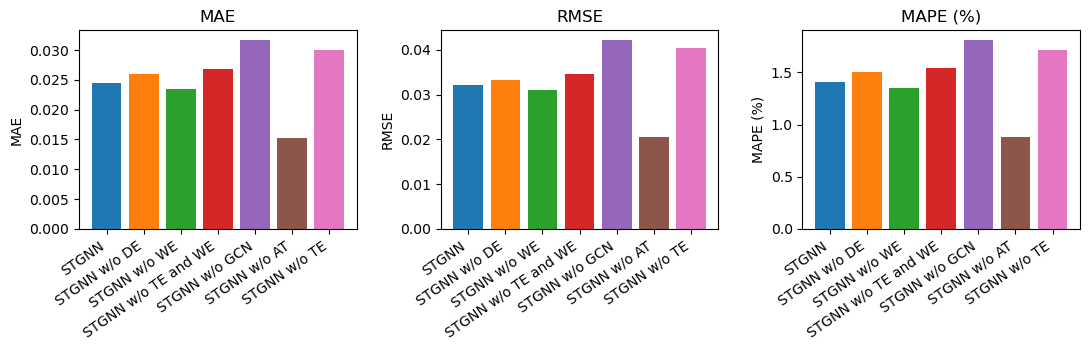

In [20]:
# Graph Comparison of different Architectures
plot_metrics_bar_avg_over_horizons_3in1(
    df_avg=TH_E5_df_avg,
    horizons=[1, 2, 4],
    save_path=TH_E5_plot_path,
)

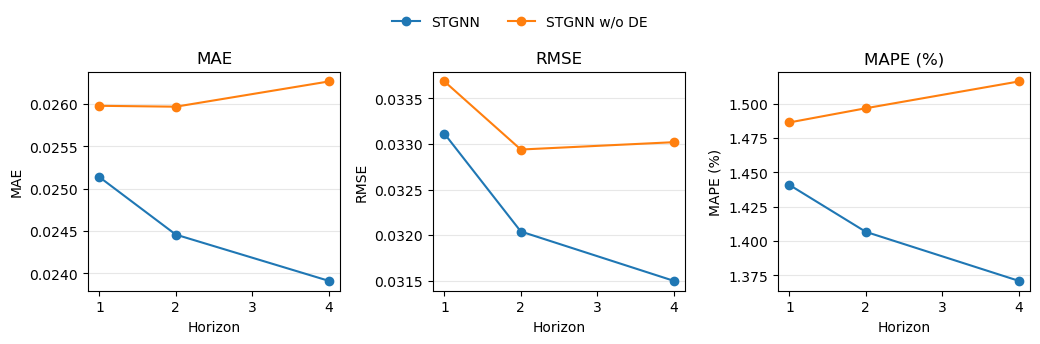

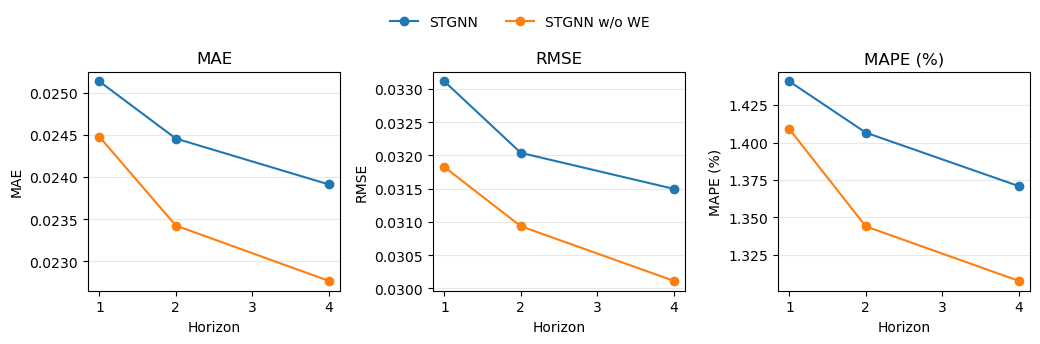

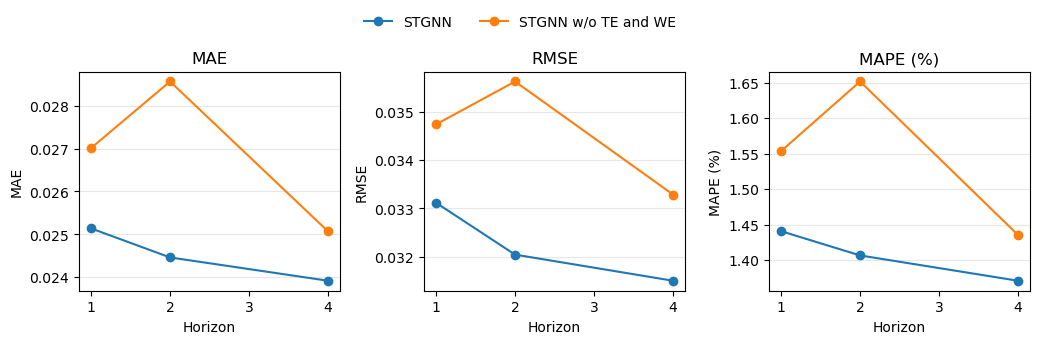

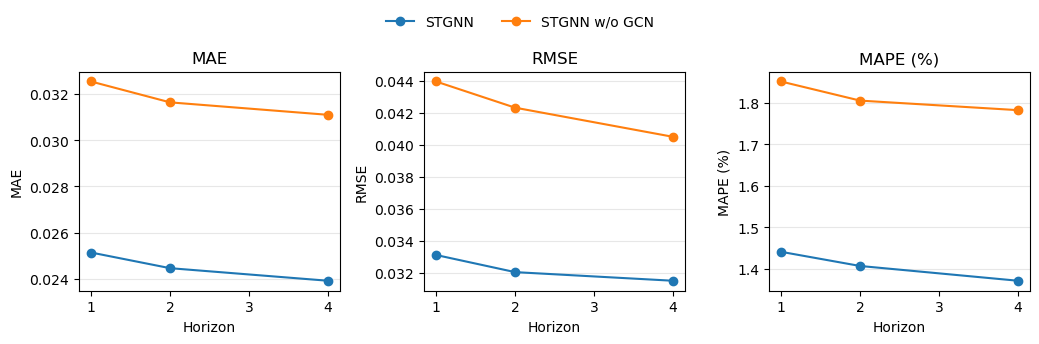

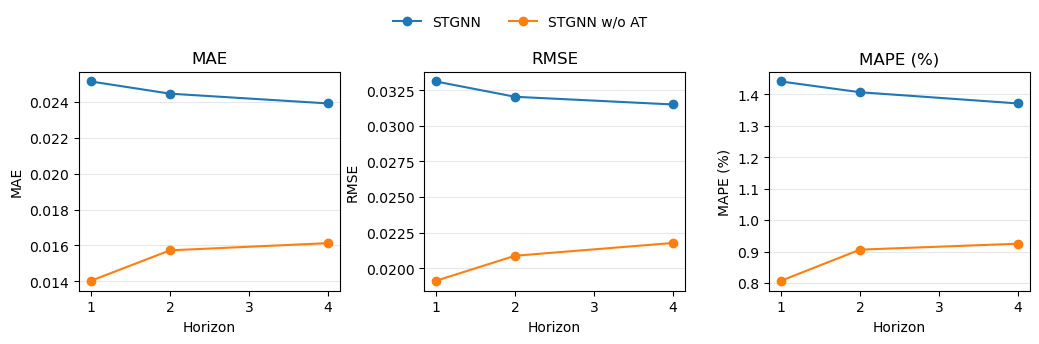

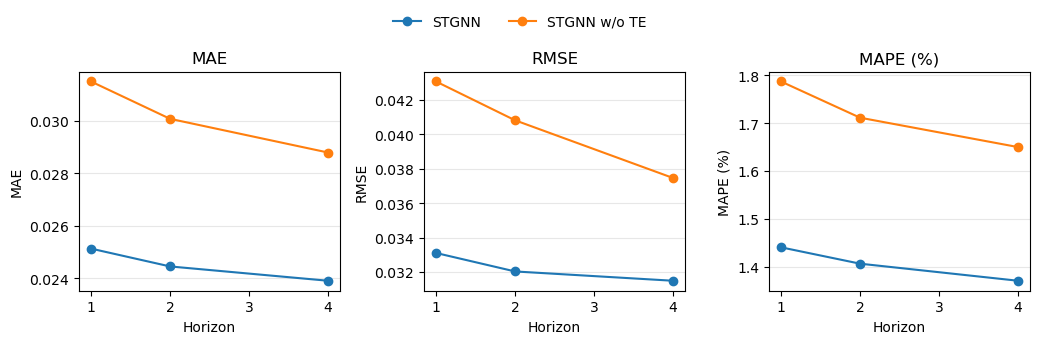

KeyError: '07_use_condat'

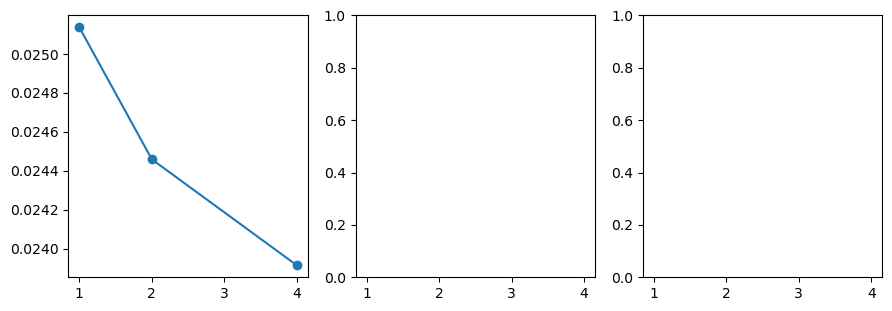

In [21]:
# Graph comparison: each ablation vs. base (per horizon)
plot_pairwise_vs_base_over_horizons(
    df_avg=TH_E5_df_avg,
    horizons=[1, 2, 4],
    save_dir=TH_E5_out_dir_graphs,
)

## 2.2. E10

In [ ]:
# Table Comparison of different Architectures
TH_E10_df_avg = load_test_metrics_per_h_avg_over_seeds(
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "01_Thuringia"
    / "02_E10"
)

TH_E10_out_dir_tables = (
    Setup.HOME_ROOT
    / "04_Results"
    / "02_Tables"
    / "05_Experiments"
    / "01_Thuringia"
    / "02_E10"
)
TH_E10_table_path = TH_E10_out_dir_tables / "exp05_02.tex"

TH_E10_out_dir_graphs = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "01_Thuringia"
    / "02_E10"
)
TH_E10_plot_path = TH_E10_out_dir_graphs / "ablation_errors_3in1.png"

TH_E10_tex = df_avg_to_latex_table_named_sorted_2dec(
    TH_E10_df_avg,
    horizons=[1, 2, 4],
    minutes={1: "15min", 2: "30min", 4: "60min"},
    save_path=TH_E10_table_path,
)

print(TH_E10_tex)

In [ ]:
# Graph Comparison of different Architectures
plot_metrics_bar_avg_over_horizons_3in1(
    df_avg=TH_E10_df_avg,
    horizons=[1, 2, 4],
    save_path=TH_E10_plot_path,
)

In [ ]:
# Graph comparison: each ablation vs. base (per horizon)
plot_pairwise_vs_base_over_horizons(
    df_avg=TH_E10_df_avg,
    horizons=[1, 2, 4],
    save_dir=TH_E10_out_dir_graphs,
)

## 2.3. Diesel

In [ ]:
# Table Comparison of different Architectures
TH_Diesel_df_avg = load_test_metrics_per_h_avg_over_seeds(
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "01_Thuringia"
    / "03_Diesel"
)

TH_Diesel_out_dir_tables = (
    Setup.HOME_ROOT
    / "04_Results"
    / "02_Tables"
    / "05_Experiments"
    / "01_Thuringia"
    / "03_Diesel"
)
TH_Diesel_table_path = TH_Diesel_out_dir_tables / "exp05_02.tex"

TH_Diesel_out_dir_graphs = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "01_Thuringia"
    / "03_Diesel"
)
TH_Diesel_plot_path = TH_Diesel_out_dir_graphs / "ablation_errors_3in1.png"

TH_Diesel_tex = df_avg_to_latex_table_named_sorted_2dec(
    TH_Diesel_df_avg,
    horizons=[1, 2, 4],
    minutes={1: "15min", 2: "30min", 4: "60min"},
    save_path=TH_Diesel_table_path,
)

print(TH_Diesel_tex)

In [ ]:
# Graph Comparison of different Architectures
plot_metrics_bar_avg_over_horizons_3in1(
    df_avg=TH_Diesel_df_avg,
    horizons=[1, 2, 4],
    save_path=TH_Diesel_plot_path,
)

In [ ]:
# Graph comparison: each ablation vs. base (per horizon)
plot_pairwise_vs_base_over_horizons(
    df_avg=TH_Diesel_df_avg,
    horizons=[1, 2, 4],
    save_dir=TH_Diesel_out_dir_graphs,
)

# 3. Hesse

## 3.1. E5

In [86]:
# Table Comparison of different Architectures
HE_E5_df_avg = load_test_metrics_per_h_avg_over_seeds(
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "02_Hesse"
    / "01_E5"
)

HE_E5_out_dir_tables = (
    Setup.HOME_ROOT
    / "04_Results"
    / "02_Tables"
    / "05_Experiments"
    / "02_Hesse"
    / "01_E5"
)
HE_E5_table_path = HE_E5_out_dir_tables / "exp05_02.tex"

HE_E5_out_dir_graphs = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "02_Hesse"
    / "01_E5"
)
HE_E5_plot_path = HE_E5_out_dir_graphs / "ablation_errors_3in1.png"

HE_E5_tex = df_avg_to_latex_table_named_sorted_2dec(
    TH_E5_df_avg,
    horizons=[1, 2, 4],
    minutes={1: "15min", 2: "30min", 4: "60min"},
    save_path=HE_E5_table_path,
)

print(HE_E5_tex)

\begin{tabular}{lccccccccc}
\toprule
Experiment & \multicolumn{3}{c}{Horizon 1 (15min)} & \multicolumn{3}{c}{Horizon 2 (30min)} & \multicolumn{3}{c}{Horizon 4 (60min)} \\
 & MAE & MAPE & RMSE & MAE & MAPE & RMSE & MAE & MAPE & RMSE \\
\midrule
STGNN & 0.03 & 1.60 & 0.04 & 0.03 & 1.58 & 0.04 & 0.03 & 1.57 & 0.04 \\
STGNN w/o DE & 0.03 & 1.49 & 0.03 & 0.03 & 1.50 & 0.03 & 0.03 & 1.52 & 0.03 \\
STGNN w/o WE & 0.02 & 0.87 & 0.02 & 0.01 & 0.83 & 0.02 & 0.02 & 0.88 & 0.02 \\
STGNN w/o TE and WE & 0.03 & 1.49 & 0.03 & 0.02 & 1.42 & 0.03 & 0.02 & 1.36 & 0.03 \\
STGNN w/o GCN & 0.03 & 1.85 & 0.04 & 0.03 & 1.81 & 0.04 & 0.03 & 1.78 & 0.04 \\
STGNN w/o AT & 0.01 & 0.73 & 0.02 & 0.01 & 0.81 & 0.02 & 0.01 & 0.85 & 0.02 \\
STGNN w/o TE & 0.03 & 1.79 & 0.04 & 0.03 & 1.71 & 0.04 & 0.03 & 1.65 & 0.04 \\
\bottomrule
\end{tabular}



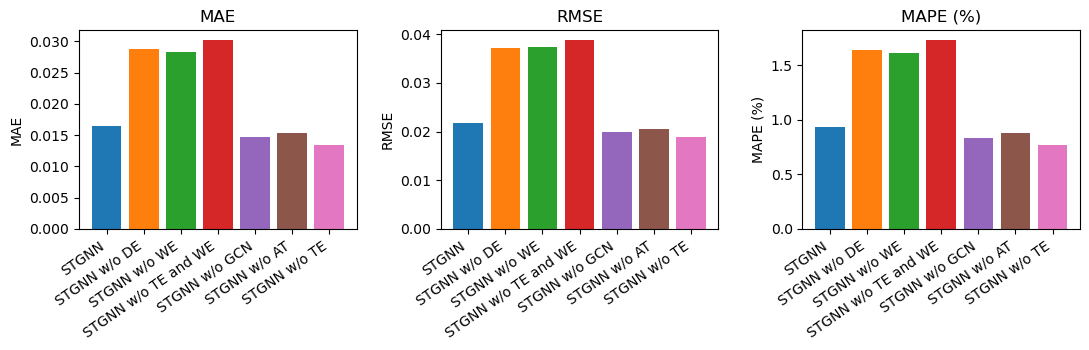

In [87]:
# Graph Comparison of different Architectures
plot_metrics_bar_avg_over_horizons_3in1(
    df_avg=HE_E5_df_avg,
    horizons=[1, 2, 4],
    save_path=HE_E5_plot_path,
)

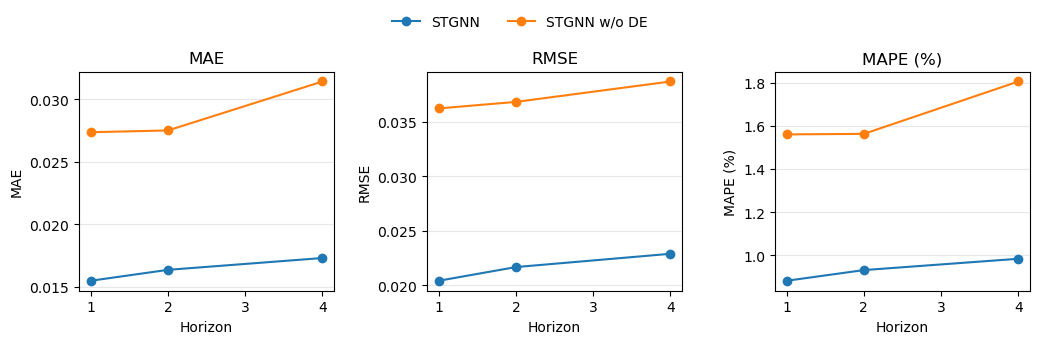

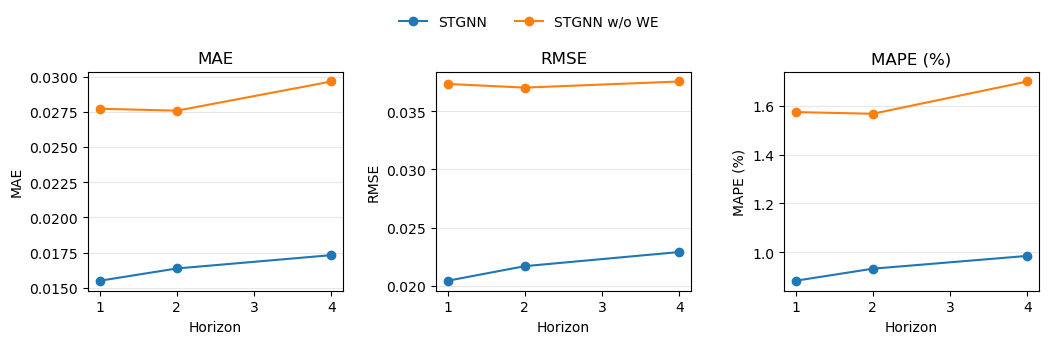

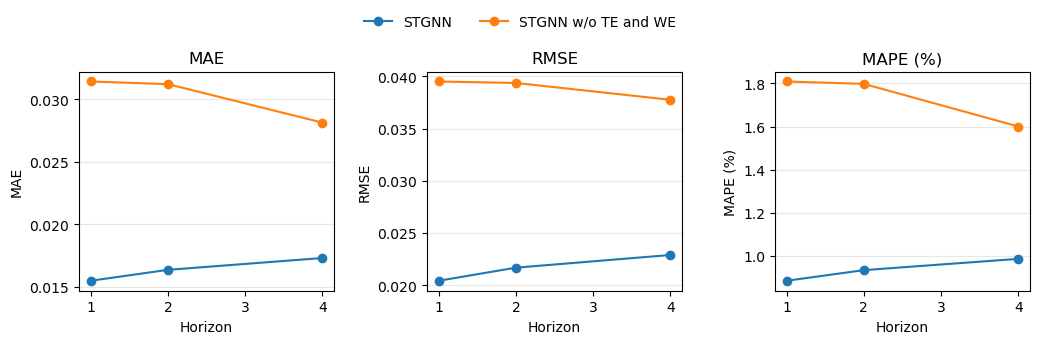

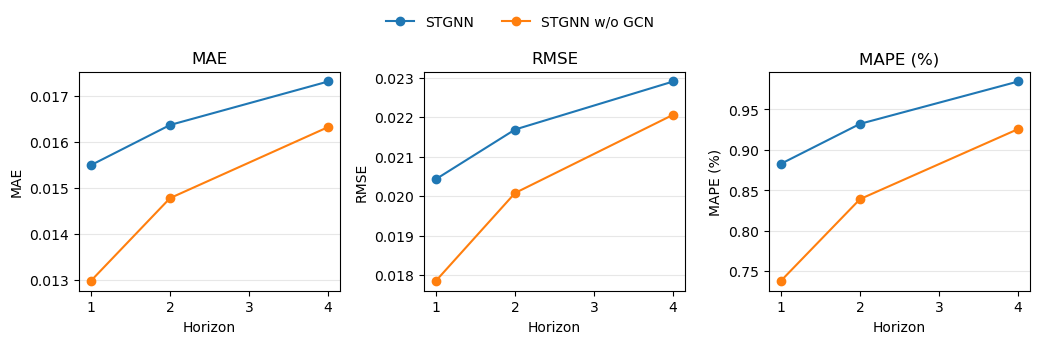

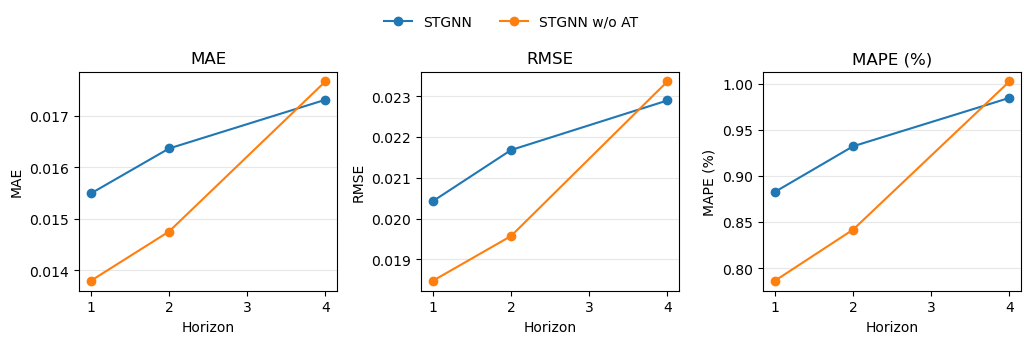

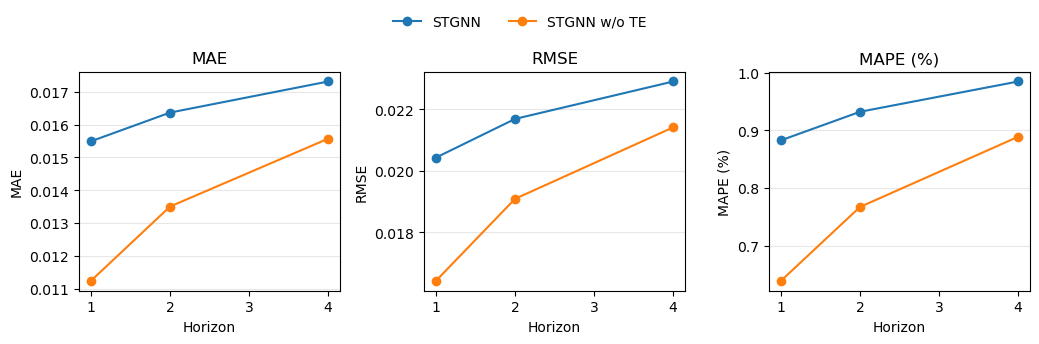

In [89]:
# Graph comparison: each ablation vs. base (per horizon)
plot_pairwise_vs_base_over_horizons(
    df_avg=HE_E5_df_avg,
    horizons=[1, 2, 4],
    save_dir=HE_E5_out_dir_graphs,
)

## 3.2. E10

In [ ]:
# Table Comparison of different Architectures
HE_E10_df_avg = load_test_metrics_per_h_avg_over_seeds(
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "02_Hesse"
    / "02_E10"
)

HE_E10_out_dir_tables = (
    Setup.HOME_ROOT
    / "04_Results"
    / "02_Tables"
    / "05_Experiments"
    / "02_Hesse"
    / "02_E10"
)
HE_E10_table_path = HE_E10_out_dir_tables / "exp05_02.tex"

HE_E10_out_dir_graphs = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "02_Hesse"
    / "02_E10"
)
HE_E10_plot_path = HE_E10_out_dir_graphs / "ablation_errors_3in1.png"

HE_E10_tex = df_avg_to_latex_table_named_sorted_2dec(
    HE_E10_df_avg,
    horizons=[1, 2, 4],
    minutes={1: "15min", 2: "30min", 4: "60min"},
    save_path=HE_E10_table_path,
)

print(HE_E10_tex)

In [ ]:
# Graph Comparison of different Architectures
plot_metrics_bar_avg_over_horizons_3in1(
    df_avg=HE_E10_df_avg,
    horizons=[1, 2, 4],
    save_path=HE_E10_plot_path,
)

In [ ]:
# Graph comparison: each ablation vs. base (per horizon)
plot_pairwise_vs_base_over_horizons(
    df_avg=HE_E10_df_avg,
    horizons=[1, 2, 4],
    save_dir=HE_E10_out_dir_graphs,
)

## 3.3. Diesel

In [ ]:
# Table Comparison of different Architectures
HE_Diesel_df_avg = load_test_metrics_per_h_avg_over_seeds(
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "02_Hesse"
    / "03_Diesel"
)

HE_Diesel_out_dir_tables = (
    Setup.HOME_ROOT
    / "04_Results"
    / "02_Tables"
    / "05_Experiments"
    / "02_Hesse"
    / "03_Diesel"
)
HE_Diesel_table_path = HE_Diesel_out_dir_tables / "exp05_02.tex"

HE_Diesel_out_dir_graphs = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "02_Experiments_Evaluation_Architecture"
    / "02_Hesse"
    / "03_Diesel"
)
HE_Diesel_plot_path = HE_Diesel_out_dir_graphs / "ablation_errors_3in1.png"

HE_Diesel_tex = df_avg_to_latex_table_named_sorted_2dec(
    HE_Diesel_df_avg,
    horizons=[1, 2, 4],
    minutes={1: "15min", 2: "30min", 4: "60min"},
    save_path=HE_Diesel_table_path,
)

print(HE_Diesel_tex)

In [ ]:
# Graph Comparison of different Architectures
plot_metrics_bar_avg_over_horizons_3in1(
    df_avg=HE_Diesel_df_avg,
    horizons=[1, 2, 4],
    save_path=HE_Diesel_plot_path,
)

In [ ]:
# Graph comparison: each ablation vs. base (per horizon)
plot_pairwise_vs_base_over_horizons(
    df_avg=HE_Diesel_df_avg,
    horizons=[1, 2, 4],
    save_dir=HE_Diesel_out_dir_graphs,
)